In [ ]:
!pip install lightgbm

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
# from skopt import BayesSearchCV
import scipy.stats as stats
import lightgbm as lgb

In [2]:
url = 'https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/df_train_0_noOutliers.csv'
df = pd.read_csv(url)

### Feature Engineering

Hacemos variables que muestren la anomalia de cada valor de las variables numericas respecto a la media

In [3]:
df['distance_mean_danceability'] = (df['danceability'] - df['danceability'].mean())
df['distance_sq_mean_danceability'] = (df['distance_mean_danceability'])**2

df['distance_mean_energy'] = (df['energy'] - df['energy'].mean())
df['distance_sq_mean_energy'] = (df['distance_mean_energy'])**2

df['distance_mean_loudness'] = (df['loudness'] - df['loudness'].mean())
df['distance_sq_mean_loudness'] = (df['distance_mean_loudness'])**2

df['distance_mean_speechiness'] = (df['speechiness'] - df['speechiness'].mean())
df['distance_sq_mean_speechiness'] = (df['distance_mean_speechiness'])**2

df['distance_mean_acousticness'] = (df['acousticness'] - df['acousticness'].mean())
df['distance_sq_mean_acousticness'] = (df['distance_mean_acousticness'])**2

df['distance_mean_liveness'] = (df['liveness'] - df['liveness'].mean())
df['distance_sq_mean_liveness'] = (df['distance_mean_liveness'])**2

df['distance_mean_valence'] = (df['valence'] - df['valence'].mean())
df['distance_sq_mean_valence'] = (df['distance_mean_valence'])**2

df['distance_mean_tempo'] = (df['tempo'] - df['tempo'].mean())
df['distance_sq_mean_tempo'] = (df['distance_mean_tempo'])**2

df['distance_mean_duration_ms'] = (df['duration_ms'] - df['duration_ms'].mean())
df['distance_sq_mean_duration_ms'] = (df['distance_mean_duration_ms'])**2

Hacemos combinaciones de variables

In [4]:
df["dance_energy"] = df["danceability"] * df["energy"]
df["happy_energy"] = df["valence"] * df["energy"]
df["acoustic_instr"] = df["acousticness"] * df["instrumentalness"]
df["duration_min"] = df["duration_ms"] / 60000

Hacemos una variable continua que mida el tiempo transcurrido en años desde el año actual (o el ultimo ano disponible)

In [5]:
df["track_age"] = 2020 - df["anio"]

In [30]:
df.to_csv('df_train_1_FE.csv', index=False)

### Creamos Nuevo Val Set

In [6]:
def imputacion_anio(anio: int):
  if anio < 1980:
    return 1970
  if anio < 1990:
    return 1980
  if anio < 2000:
    return 1990
  if anio < 2010:
    return 2000
  if anio < 2015:
    return 2010
  return anio

**MUCHA ATENCION ACA PORQUE LAS VARIABLES NUEVAS LAS ESTAMOS CREANDO SOBRE PROMEDIOS DE LA BASE DE VALIDACION, Y LOS MODELOS FUERON ENTRENADOS SOBRE PROMEDIOS DE LA BASE DE TRAIN** -> Puede haber Data Leakage pero sobretodo puede fallar porque esta pensando en diferencias sobre la media general de train

In [ ]:
### CON DATA LEAKAGE ###

# df_val = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/base_val.csv')

# # Armamos variable anio
# df_val['anio'] = df_val['track_album_release_date'].apply(lambda x: x.split('-')[0])
# df_val['anio'] = df_val['anio'].astype(int)
# df_val['grupo_anio'] = df_val['anio'].apply(imputacion_anio)

# # Feature Engineering
# df_val['distance_mean_danceability'] = (df_val['danceability'] - df_val['danceability'].mean())
# df_val['distance_sq_mean_danceability'] = (df_val['distance_mean_danceability'])**2
# df_val['distance_mean_energy'] = (df_val['energy'] - df_val['energy'].mean())
# df_val['distance_sq_mean_energy'] = (df_val['distance_mean_energy'])**2
# df_val['distance_mean_loudness'] = (df_val['loudness'] - df_val['loudness'].mean())
# df_val['distance_sq_mean_loudness'] = (df_val['distance_mean_loudness'])**2
# df_val['distance_mean_speechiness'] = (df_val['speechiness'] - df_val['speechiness'].mean())
# df_val['distance_sq_mean_speechiness'] = (df_val['distance_mean_speechiness'])**2
# df_val['distance_mean_acousticness'] = (df_val['acousticness'] - df_val['acousticness'].mean())
# df_val['distance_sq_mean_acousticness'] = (df_val['distance_mean_acousticness'])**2
# df_val['distance_mean_liveness'] = (df_val['liveness'] - df_val['liveness'].mean())
# df_val['distance_sq_mean_liveness'] = (df_val['distance_mean_liveness'])**2
# df_val['distance_mean_valence'] = (df_val['valence'] - df_val['valence'].mean())
# df_val['distance_sq_mean_valence'] = (df_val['distance_mean_valence'])**2
# df_val['distance_mean_tempo'] = (df_val['tempo'] - df_val['tempo'].mean())
# df_val['distance_sq_mean_tempo'] = (df_val['distance_mean_tempo'])**2
# df_val['distance_mean_duration_ms'] = (df_val['duration_ms'] - df_val['duration_ms'].mean())
# df_val['distance_sq_mean_duration_ms'] = (df_val['distance_mean_duration_ms'])**2
# df_val["dance_energy"] = df_val["danceability"] * df_val["energy"]
# df_val["happy_energy"] = df_val["valence"] * df_val["energy"]
# df_val["acoustic_instr"] = df_val["acousticness"] * df_val["instrumentalness"]
# df_val["duration_min"] = df_val["duration_ms"] / 60000
# df_val["track_age"] = 2020 - df_val["anio"]

In [7]:
### SIN DATA LEAKAGE ###

df_val2 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/base_val.csv')

# Armamos variable anio
df_val2['anio'] = df_val2['track_album_release_date'].apply(lambda x: x.split('-')[0])
df_val2['anio'] = df_val2['anio'].astype(int)
df_val2['grupo_anio'] = df_val2['anio'].apply(imputacion_anio)

# Feature Engineering
df_val2['distance_mean_danceability'] = (df_val2['danceability'] - df['danceability'].mean())
df_val2['distance_sq_mean_danceability'] = (df_val2['distance_mean_danceability'])**2
df_val2['distance_mean_energy'] = (df_val2['energy'] - df['energy'].mean())
df_val2['distance_sq_mean_energy'] = (df_val2['distance_mean_energy'])**2
df_val2['distance_mean_loudness'] = (df_val2['loudness'] - df['loudness'].mean())
df_val2['distance_sq_mean_loudness'] = (df_val2['distance_mean_loudness'])**2
df_val2['distance_mean_speechiness'] = (df_val2['speechiness'] - df['speechiness'].mean())
df_val2['distance_sq_mean_speechiness'] = (df_val2['distance_mean_speechiness'])**2
df_val2['distance_mean_acousticness'] = (df_val2['acousticness'] - df['acousticness'].mean())
df_val2['distance_sq_mean_acousticness'] = (df_val2['distance_mean_acousticness'])**2
df_val2['distance_mean_liveness'] = (df_val2['liveness'] - df['liveness'].mean())
df_val2['distance_sq_mean_liveness'] = (df_val2['distance_mean_liveness'])**2
df_val2['distance_mean_valence'] = (df_val2['valence'] - df['valence'].mean())
df_val2['distance_sq_mean_valence'] = (df_val2['distance_mean_valence'])**2
df_val2['distance_mean_tempo'] = (df_val2['tempo'] - df['tempo'].mean())
df_val2['distance_sq_mean_tempo'] = (df_val2['distance_mean_tempo'])**2
df_val2['distance_mean_duration_ms'] = (df_val2['duration_ms'] - df['duration_ms'].mean())
df_val2['distance_sq_mean_duration_ms'] = (df_val2['distance_mean_duration_ms'])**2
df_val2["dance_energy"] = df_val2["danceability"] * df_val2["energy"]
df_val2["happy_energy"] = df_val2["valence"] * df_val2["energy"]
df_val2["acoustic_instr"] = df_val2["acousticness"] * df_val2["instrumentalness"]
df_val2["duration_min"] = df_val2["duration_ms"] / 60000
df_val2["track_age"] = 2020 - df_val2["anio"]

In [26]:
df_val2.columns = df_val2.columns.astype(str)

In [28]:
df_val2.to_csv('df_val_FE_sinLeak.csv', index=False)

In [8]:
dummies_genre_val = pd.get_dummies(df_val2['playlist_genre']).astype(int)
dummies_subgenre_val = pd.get_dummies(df_val2['playlist_subgenre']).astype(int)
dummies_grupo_anio_val = pd.get_dummies(df_val2['grupo_anio']).astype(int)
variables_ML = ['danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'distance_mean_danceability',
       'distance_sq_mean_danceability', 'distance_mean_energy',
       'distance_sq_mean_energy', 'distance_mean_loudness',
       'distance_sq_mean_loudness', 'distance_mean_speechiness',
       'distance_sq_mean_speechiness', 'distance_mean_acousticness',
       'distance_sq_mean_acousticness', 'distance_mean_liveness',
       'distance_sq_mean_liveness', 'distance_mean_valence',
       'distance_sq_mean_valence', 'distance_mean_tempo',
       'distance_sq_mean_tempo', 'distance_mean_duration_ms',
       'distance_sq_mean_duration_ms', 'dance_energy', 'happy_energy',
       'acoustic_instr', 'duration_min', 'track_age']

df_val_ML = pd.concat([df_val2[variables_ML], dummies_genre_val[['r&b']], dummies_subgenre_val[['neo soul']], dummies_grupo_anio_val], axis=1)


In [9]:
df_val_ML.columns = df_val_ML.columns.astype(str)

### Particion de datos

In [10]:
dummies_genre = pd.get_dummies(df['playlist_genre']).astype(int)
dummies_subgenre = pd.get_dummies(df['playlist_subgenre']).astype(int)
dummies_grupo_anio = pd.get_dummies(df['grupo_anio']).astype(int)
variables_ML = ['danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'distance_mean_danceability',
       'distance_sq_mean_danceability', 'distance_mean_energy',
       'distance_sq_mean_energy', 'distance_mean_loudness',
       'distance_sq_mean_loudness', 'distance_mean_speechiness',
       'distance_sq_mean_speechiness', 'distance_mean_acousticness',
       'distance_sq_mean_acousticness', 'distance_mean_liveness',
       'distance_sq_mean_liveness', 'distance_mean_valence',
       'distance_sq_mean_valence', 'distance_mean_tempo',
       'distance_sq_mean_tempo', 'distance_mean_duration_ms',
       'distance_sq_mean_duration_ms', 'dance_energy', 'happy_energy',
       'acoustic_instr', 'duration_min', 'track_age']

df_ML = pd.concat([df[variables_ML], dummies_genre[['r&b']], dummies_subgenre[['neo soul']], dummies_grupo_anio], axis=1)

X = df_ML.copy()
y = df['track_popularity'].copy()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

### Quick RFR

In [ ]:
rfr = RandomForestRegressor(n_jobs=-1, random_state=42)
rfr.fit(X_train, y_train)
scores = cross_val_score(rfr, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print("RMSE por fold:", -scores)
print("RMSE promedio:", -np.mean(scores))
print("Desvío estándar del RMSE:", np.std(-scores))

y_pred_rfr_base = rfr.predict(X_test)
print('Modelo RFR base - Test')
print(f'Middle Square Error = {mean_squared_error(y_test, y_pred_rfr_base):.2f}')
print(f'Root Middle Square Error = {np.sqrt(y_test, y_pred_rfr_base):.2f}')   # Por cuanto erro, en unidades de y
print(f'R2 = {r2_score(y_test, y_pred_rfr_base):.2f}')

RMSE por fold: [21.42902103 21.35686444 21.45016676 21.10255464 21.12214739]
RMSE promedio: 21.29215085239397
Desvío estándar del RMSE: 0.1501587318819576
Modelo RFR base - Test
Middle Square Error = 433.24


NameError: name 'root_mean_squared_error' is not defined

In [ ]:
np.sqrt(mean_squared_error(y_test, y_pred_rfr_base))

np.float64(20.814320819172934)

### Rotation Forest

In [13]:
!pip install aeon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 30.5 MB/s eta 0:00:00


#### Primer Rotation Forest

In [14]:
# Importación del estimador oficial de aeon
from aeon.regression.sklearn import RotationForestRegressor

regressor = RotationForestRegressor(n_estimators=100, random_state=42)

# 4. Entrenar el modelo
regressor.fit(X_train, y_train)

print('TRAIN')
y_pred = regressor.predict(X_train)
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_train, y_pred):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_train, y_pred):.4f}")

print('TEST')
y_pred = regressor.predict(X_test)
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_test, y_pred):.4f}")

TRAIN
Error Cuadrático Medio (MSE): 13.2254
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 3.6367
Coeficiente de Determinación (R²): 0.9788
TEST
Error Cuadrático Medio (MSE): 430.1516
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 20.7401
Coeficiente de Determinación (R²): 0.3197


Error Cuadrático Medio (MSE): 430.1516

Raiz Cuadrada del Error Cuadrático Medio (RMSE): 20.7401

Coeficiente de Determinación (R²): 0.3197

Corremos cross validation -> 19 mins

In [ ]:
scores = cross_val_score(regressor, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print("RMSE por fold:", -scores)
print("RMSE promedio:", -np.mean(scores))
print("Desvío estándar del RMSE:", np.std(-scores))

RMSE por fold: [21.59044722 21.3684258  21.42535297 21.12540314 21.20743929]
RMSE promedio: 21.34341368219985
Desvío estándar del RMSE: 0.16394075455952298


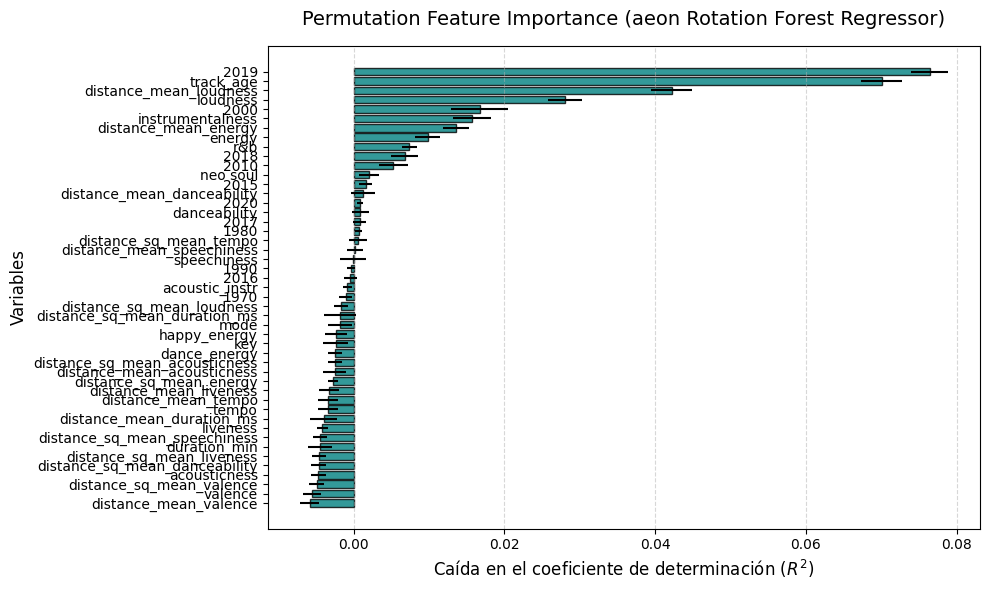


--- Tabla de Importancias por Permutación ---
                     Variable  Importancia_Media  Desviacion_Std
                         2019           0.076392        0.002396
                    track_age           0.070059        0.002720
       distance_mean_loudness           0.042187        0.002713
                     loudness           0.027999        0.002255
                         2000           0.016712        0.003771
             instrumentalness           0.015732        0.002514
         distance_mean_energy           0.013574        0.001695
                       energy           0.009862        0.001661
                          r&b           0.007382        0.001006
                         2018           0.006800        0.001775
                         2010           0.005296        0.001934
                     neo soul           0.002057        0.001335
                         2015           0.001623        0.000889
   distance_mean_danceability           0.0

In [ ]:
result = permutation_importance(
    regressor,
    X_test,
    y_test,
    scoring='r2',       # Usamos R²; mide cuánto cae el porcentaje de varianza explicado
    n_repeats=10,
    random_state=42,
    n_jobs=1           # Changed from -1 to 1 to avoid multiprocessing issues
)

# 5. Organizar los resultados en un DataFrame ordenado
# Use X_train.columns as feature names
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Importancia_Media': result.importances_mean,
    'Desviacion_Std': result.importances_std
}).sort_values(by='Importancia_Media', ascending=True) # Ascendente para la gráfica de barras horizontales

# 6. Graficar la Permutation Importance con barras de error
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df['Variable'],
    importance_df['Importancia_Media'],
    xerr=importance_df['Desviacion_Std'],
    color='teal',
    edgecolor='black',
    alpha=0.8
)
plt.title("Permutation Feature Importance (aeon Rotation Forest Regressor)", fontsize=14, pad=15)
plt.xlabel("Caída en el coeficiente de determinación ($R^2$)", fontsize=12)
plt.ylabel("Variables", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Imprimir los valores numéricos exactos por consola
print("\n--- Tabla de Importancias por Permutación ---")
print(importance_df.sort_values(by='Importancia_Media', ascending=False).to_string(index=False))

In [ ]:
vars_mas_impo = list(importance_df.sort_values(by='Importancia_Media', ascending=False).head(12)['Variable'].values)
vars_mas_impo

['2019',
 'track_age',
 'distance_mean_loudness',
 'loudness',
 '2000',
 'instrumentalness',
 'distance_mean_energy',
 'energy',
 'r&b',
 '2018',
 '2010',
 'neo soul']

#### Hago submission

#### Submission 1: variable distances con media de validation -> R^2 de Kaggle: 0,12350

In [ ]:
X_validation = df_val_ML[list(X_train.columns)]

y_pred = regressor.predict(X_validation)

In [ ]:
submission_df_cb = pd.DataFrame({
    'ID': df_val['Unnamed: 0'],
    'track_popularity': y_pred
})

submission_df_cb.to_csv('submission_rotationForest.csv', index=False)

#### Submission 2: variables distances con media de train -> R^2 de Kaggle: 0,20690

In [19]:
X_validation2 = df_val_ML[list(X_train.columns)]

y_pred2 = regressor.predict(X_validation2)

In [20]:
submission_df_cb = pd.DataFrame({
    'ID': df_val2['Unnamed: 0'],
    'track_popularity': y_pred2
})

submission_df_cb.to_csv('submission_rotationForest_sinLeakage.csv', index=False)

#### Para evaluar importancia de las features

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.tree import DecisionTreeRegressor
from sklearn.decomposition import PCA

class RotationForestRegressorWithImportance(BaseEstimator, RegressorMixin):
    def __init__(self, n_estimators=30, n_features_per_subset=3):
        self.n_estimators = n_estimators
        self.n_features_per_subset = n_features_per_subset
        self.estimators = []
        self.rotation_matrices = []
        self.feature_importances_ = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.estimators = []
        self.rotation_matrices = []

        # Guardaremos las importancias transformadas de cada estimador
        all_importances = np.zeros((self.n_estimators, n_features))

        for i in range(self.n_estimators):
            permuted_features = np.random.permutation(n_features)
            subsets = [permuted_features[j:j + self.n_features_per_subset]
                       for j in range(0, n_features, self.n_features_per_subset)]

            R_block = np.zeros((n_features, n_features))

            for subset in subsets:
                if len(subset) == 0:
                    continue
                bootstrap_idx = np.random.choice(n_samples, size=int(0.75 * n_samples), replace=True)
                X_subset = X[bootstrap_idx][:, subset]

                pca = PCA(n_components=len(subset))
                pca.fit(X_subset)

                for local_idx, global_idx in enumerate(subset):
                    R_block[global_idx, subset] = pca.components_[:, local_idx]

            self.rotation_matrices.append(R_block)
            X_rotated = X.dot(R_block)

            tree = DecisionTreeRegressor(random_state=i)
            tree.fit(X_rotated, y)
            self.estimators.append(tree)

            # --- PROYECTAR IMPORTANCIAS AL ESPACIO ORIGINAL ---
            # Tomamos la importancia de los componentes asignada por el árbol
            tree_importance = tree.feature_importances_
            # Proyectamos usando el valor absoluto de la matriz de rotación
            all_importances[i, :] = np.abs(R_block).dot(tree_importance)

        # Promediamos la importancia a través de todos los árboles del bosque
        raw_importances = np.mean(all_importances, axis=0)
        # Normalizamos para que sumen 1 (estándar de scikit-learn)
        self.feature_importances_ = raw_importances / np.sum(raw_importances)

        return self

    def predict(self, X):
        predictions = np.zeros((X.shape[0], self.n_estimators))
        for i in range(self.n_estimators):
            X_rotated = X.dot(self.rotation_matrices[i])
            predictions[:, i] = self.estimators[i].predict(X_rotated)
        return np.mean(predictions, axis=1)

# Entrenar modelo
model = RotationForestRegressorWithImportance(n_estimators=100, n_features_per_subset=2)
model.fit(X_train, y_train)

# --- GRAFICAR LOS RESULTADOS ---
indices = np.argsort(model.feature_importances_)[::-1]

plt.figure(figsize=(8, 5))
plt.title("Importancia de las Variables (Rotation Forest)")
plt.bar(range(X.shape[1]), model.feature_importances_[indices], color="royalblue", align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices])
plt.xlim([-1, X.shape[1]])
plt.ylabel("Importancia Relativa")
plt.tight_layout()
plt.show()

#### Rotation Forest escalado

In [22]:
columnas_continuas = list(X_train.select_dtypes(include='float').columns) + ['track_age']

In [ ]:
preprocesador = ColumnTransformer(
    transformers=[
        # Aplicar StandardScaler SOLO a las continuas
        ('escalador_num', StandardScaler(), columnas_continuas)
    ],
    # remainder='passthrough' indica que todo lo que NO esté en la lista anterior
    # (las variables dummies) pase de largo directamente sin ser transformado
    remainder='passthrough'
)

pipeline_final = Pipeline([
    ('preprocesamiento', preprocesador),
    ('rotation_forest', RotationForestRegressor(n_estimators=100, random_state=42))
])

pipeline_final.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('escalador_num',
                                                  StandardScaler(),
                                                  ['danceability', 'energy',
                                                   'loudness', 'speechiness',
                                                   'acousticness',
                                                   'instrumentalness',
                                                   'liveness', 'valence',
                                                   'tempo',
                                                   'distance_mean_danceability',
                                                   'distance_sq_mean_danceability',
                                                   'distance_mean_energy',
                                                   'distance_sq_mean_energy',
                                                   '...
                                                   'distance_sq_mean_acousticness',
                                                   'distance_mean_liveness',
                                                   'distance_sq_mean_liveness',
                                                   'distance_mean_valence',
                                                   'distance_sq_mean_valence',
                                                   'distance_mean_tempo',
                                                   'distance_sq_mean_tempo',
                                                   'distance_mean_duration_ms',
                                                   'distance_sq_mean_duration_ms',
                                                   'dance_energy',
                                                   'happy_energy',
                                                   'acoustic_instr', ...])])),
                ('rotation_forest',
                 RotationForestRegressor(n_estimators=100, random_state=42))])

In [ ]:
y_pred_pipeline_final = pipeline_final.predict(X_test)

print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred_pipeline_final):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred_pipeline_final)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_test, y_pred_pipeline_final):.4f}")

Error Cuadrático Medio (MSE): 431.1641
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 20.7645
Coeficiente de Determinación (R²): 0.3181


Probamos ahora sin dummies

In [ ]:
pipeline_final.fit(X_train[columnas_continuas], y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('escalador_num',
                                                  StandardScaler(),
                                                  ['danceability', 'energy',
                                                   'loudness', 'speechiness',
                                                   'acousticness',
                                                   'instrumentalness',
                                                   'liveness', 'valence',
                                                   'tempo',
                                                   'distance_mean_danceability',
                                                   'distance_sq_mean_danceability',
                                                   'distance_mean_energy',
                                                   'distance_sq_mean_energy',
                                                   '...
                                                   'distance_sq_mean_acousticness',
                                                   'distance_mean_liveness',
                                                   'distance_sq_mean_liveness',
                                                   'distance_mean_valence',
                                                   'distance_sq_mean_valence',
                                                   'distance_mean_tempo',
                                                   'distance_sq_mean_tempo',
                                                   'distance_mean_duration_ms',
                                                   'distance_sq_mean_duration_ms',
                                                   'dance_energy',
                                                   'happy_energy',
                                                   'acoustic_instr', ...])])),
                ('rotation_forest',
                 RotationForestRegressor(n_estimators=100, random_state=42))])

In [ ]:
print('Prediccion TRAIN')
y_train_pred_pipeline_final = pipeline_final.predict(X_train[columnas_continuas])
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_train, y_train_pred_pipeline_final):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_train, y_train_pred_pipeline_final)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_train, y_train_pred_pipeline_final):.4f}")

print('Prediccion TEST')
y_pred_pipeline_final = pipeline_final.predict(X_test[columnas_continuas])
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred_pipeline_final):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred_pipeline_final)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_test, y_pred_pipeline_final):.4f}")

Prediccion TRAIN
Error Cuadrático Medio (MSE): 14.5944
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 3.8203
Coeficiente de Determinación (R²): 0.9766
Prediccion TEST
Error Cuadrático Medio (MSE): 430.2015
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 20.7413
Coeficiente de Determinación (R²): 0.3196


Probamos tratando de capturar no linealidades

In [ ]:
from sklearn.compose import TransformedTargetRegressor

# Envolver el pipeline para que estabilice la variable 'y'
modelo_final_estabilizado = TransformedTargetRegressor(
    regressor=pipeline_final, # Tu pipeline actual con ColumnTransformer
    func=np.log1p,            # Aplica log(x + 1) para estabilizar la varianza de y
    inverse_func=np.expm1     # Deshace el logaritmo al momento de medir el RMSE
)

# Ahora entrenás este objeto contenedor
modelo_final_estabilizado.fit(X_train[columnas_continuas], y_train)

print('Prediccion TRAIN')
y_train_pred_pipeline_final = modelo_final_estabilizado.predict(X_train[columnas_continuas])
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_train, y_train_pred_pipeline_final):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_train, y_train_pred_pipeline_final)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_train, y_train_pred_pipeline_final):.4f}")

print('Prediccion TEST')
y_pred_pipeline_final = modelo_final_estabilizado.predict(X_test[columnas_continuas])
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred_pipeline_final):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred_pipeline_final)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_test, y_pred_pipeline_final):.4f}")

Prediccion TRAIN
Error Cuadrático Medio (MSE): 18.4842
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 4.2993
Coeficiente de Determinación (R²): 0.9703
Prediccion TEST
Error Cuadrático Medio (MSE): 560.1176
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 23.6668
Coeficiente de Determinación (R²): 0.1141


Probamos otra manera de modelar no linealidades

In [23]:
from sklearn.preprocessing import QuantileTransformer, PowerTransformer

preprocesador_avanzado = ColumnTransformer(
    transformers=[
        # Convierte las variables a una distribución normal, reduciendo el impacto de outliers
        # y ayudando al PCA a encontrar mejores componentes estables.
        ('transformacion_no_lineal', QuantileTransformer(output_distribution='normal', random_state=42), columnas_continuas)
    ],
    remainder='passthrough'
)

pipeline_avanzado = Pipeline([
    ('preprocesamiento', preprocesador_avanzado),
    ('rotation_forest', RotationForestRegressor(n_estimators=100, random_state=42))
])

# Ahora entrenás este objeto contenedor
pipeline_avanzado.fit(X_train[columnas_continuas], y_train)

print('Prediccion TRAIN')
y_train_pred_pipeline_final = pipeline_avanzado.predict(X_train[columnas_continuas])
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_train, y_train_pred_pipeline_final):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_train, y_train_pred_pipeline_final)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_train, y_train_pred_pipeline_final):.4f}")

print('Prediccion TEST')
y_pred_pipeline_final = pipeline_avanzado.predict(X_test[columnas_continuas])
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred_pipeline_final):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred_pipeline_final)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_test, y_pred_pipeline_final):.4f}")

Prediccion TRAIN
Error Cuadrático Medio (MSE): 14.5944
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 3.8203
Coeficiente de Determinación (R²): 0.9766
Prediccion TEST
Error Cuadrático Medio (MSE): 427.5836
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 20.6781
Coeficiente de Determinación (R²): 0.3237


#### Submission 3: variables distance sin leakage + transformaciones no lineales -> **R^2 de Kaggle: 0,21393**

In [24]:
X_validation2 = df_val_ML[list(X_train.columns)]

y_pred3 = pipeline_avanzado.predict(X_validation2)

In [25]:
submission_df_cb = pd.DataFrame({
    'ID': df_val2['Unnamed: 0'],
    'track_popularity': y_pred3
})

submission_df_cb.to_csv('submission_rotationForest_sinLeakage_NoLineal.csv', index=False)

#### Segundo RotationForest

No cambia nada

In [ ]:
regressor2 = RotationForestRegressor(n_estimators=200, min_group=5, max_group=8, remove_proportion=0.3, random_state=42)

# 4. Entrenar el modelo
regressor2.fit(X_train, y_train)

# 5. Realizar predicciones y evaluar el rendimiento
y_pred_2 = regressor2.predict(X_test)

print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred_2):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred_2)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_test, y_pred_2):.4f}")

Error Cuadrático Medio (MSE): 430.2645
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 20.7428
Coeficiente de Determinación (R²): 0.3195


In [ ]:
# Ajustamos los árboles base para que no sobreajusten en el espacio transformado
base_tree_restrictivo = DecisionTreeRegressor(
    max_depth=7,               # Bajamos un poco más la profundidad para forzar generalización
    min_samples_split=50,       # Exigimos más muestras para abrir ramas
    min_samples_leaf=25,        # Hojas más grandes para evitar memorizar ruido
    random_state=42
)

pipeline_final = Pipeline([
    # Transformación que te dio el mejor resultado
    ('quantile', QuantileTransformer(output_distribution='normal', random_state=42)),

    # Rotation Forest enfocado puramente en las variables continuas
    ('rotation_forest', RotationForestRegressor(
        n_estimators=150,       # Subimos a 150 para reducir la varianza del ensamble
        min_group=4,            # Forzamos grupos de 4 variables continuas para el PCA
        max_group=6,
        remove_proportion=0.25, # Conservamos el 75% de las filas para estabilizar el PCA
        base_estimator=base_tree_restrictivo,
        random_state=42,
        n_jobs=-1
    ))
])

# 3. ENTRENAR Y EVALUAR
pipeline_final.fit(X_train[columnas_continuas], y_train)

print(f"Nuevo R² train: {pipeline_final.score(X_train[columnas_continuas], y_train):.4f}")
print(f"Nuevo R² test: {pipeline_final.score(X_test[columnas_continuas], y_test):.4f}")

Nuevo R² train: 0.2290
Nuevo R² test: 0.1610


### LightGBM

https://lightgbm.readthedocs.io/en/stable/index.html

Corremos el modelo estandar

In [ ]:
# Initialize and train the LightGBM Regressor model
'''
PARAMETERS DEFAULT:
boosting_type: str='gbdt', num_leaves: int=31, max_depth: int=-1, learning_rate: float=0.1, n_estimators: int=100, subsample_for_bin: int=200000,
objective: Optional[Union[str, _LGBM_ScikitCustomObjectiveFunction]]=None, class_weight: Optional[Union[Dict, str]]=None, min_split_gain: float=0.0,
min_child_weight: float=0.001, min_child_samples: int=20, subsample: float=1.0, subsample_freq: int=0, colsample_bytree: float=1.0,
reg_alpha: float=0.0, reg_lambda: float=0.0
'''
lgbm = lgb.LGBMRegressor(random_state=42)

scores = cross_val_score(lgbm, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print("RMSE por fold:", -scores)
print("RMSE promedio:", -np.mean(scores))
print("Desvío estándar del RMSE:", np.std(-scores))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006480 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8005
[LightGBM] [Info] Number of data points in the train set: 16809, number of used features: 47
[LightGBM] [Info] Start training from score 44.507883
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007620 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8004
[LightGBM] [Info] Number of data points in the train set: 16809, number of used features: 47
[LightGBM] [Info] Start training from score 44.456898
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM]

In [ ]:
lgbm.fit(X_train, y_train)

# Make predictions on the test set
y_pred = lgbm.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"LightGBM Model Performance:")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009579 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8005
[LightGBM] [Info] Number of data points in the train set: 21012, number of used features: 47
[LightGBM] [Info] Start training from score 44.555778
LightGBM Model Performance:
R-squared: 0.2075
RMSE: 22.3852


Probamos una configuracion en particular

In [ ]:
print("Starting training...")
# train
gbm = lgb.LGBMRegressor(num_leaves=31, learning_rate=0.05, n_estimators=20)
gbm.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric="l1", callbacks=[lgb.early_stopping(5)])

print("Starting predicting...")
# predict
y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration_)

# eval
rmse_test = mean_squared_error(y_test, y_pred) ** 0.5
print(f"The RMSE of prediction is: {rmse_test}")
print(f"The R2 of prediction is: {r2_score(y_test, y_pred)}")

# feature importances
print(f"Feature importances:")
for i, feat in enumerate(X_train.columns):
    print(f"{feat}: {gbm.feature_importances_[i]}")

Starting training...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009615 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8005
[LightGBM] [Info] Number of data points in the train set: 21012, number of used features: 47
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 44.555778
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[20]	valid_0's l1: 19.7894	valid_0's l2: 550.956
Starting predicting...
The RMSE of prediction is: 23.472443604134835
The R2 of prediction is: 0.12859938270688265
Feature importances:
danceability: 23
energy: 44
key: 2
loudness: 52
mode: 0
speechiness: 33
acousticness: 33
instrumentalness: 44
liveness: 5
valence: 6
tempo: 13
distance_mean_danceability: 7
distance_sq

Empezamos a tunear el modelo

In [ ]:
# modelo base
model = lgb.LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=-1
)

# espacio de búsqueda
param_dist = {
    # boosting
    "n_estimators": stats.randint(200, 1200),
    "learning_rate": stats.uniform(0.01, 0.09),
    # complejidad
    "num_leaves": stats.randint(20, 150),
    "max_depth": [-1, 5, 8, 10, 15],
    # regularización
    "min_child_samples": stats.randint(5, 100),
    # bagging
    "subsample": stats.uniform(0.6, 0.4),
    "colsample_bytree": stats.uniform(0.6, 0.4),
    # regularización L1/L2
    "reg_alpha": stats.uniform(0, 2),
    "reg_lambda": stats.uniform(0, 2),
}

# búsqueda
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=30,          # clave para tiempo
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# entrenamiento
random_search.fit(X_train, y_train)

# resultados
print("Best params:")
print(random_search.best_params_)

print("\nBest RMSE:")
print(-random_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008718 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8005
[LightGBM] [Info] Number of data points in the train set: 21012, number of used features: 47
[LightGBM] [Info] Start training from score 44.555778
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

Lo que devolvio:

**{'colsample_bytree': np.float64(0.8428136990746738), 'learning_rate': np.float64(0.0348399263820289), 'max_depth': 15, 'min_child_samples': 19, 'n_estimators': 1012, 'num_leaves': 84, 'reg_alpha': np.float64(0.03127281348238786), 'reg_lambda': np.float64(0.8468029614127393), 'subsample': np.float64(0.7579526072702278)}**

In [ ]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": random_search.best_estimator_.booster_.feature_importance(
        importance_type='gain'
    )
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance)

                          feature    importance
33                      track_age  1.470202e+07
3                        loudness  6.663371e+06
5                     speechiness  6.512474e+06
6                    acousticness  6.227428e+06
28   distance_sq_mean_duration_ms  6.053822e+06
7                instrumentalness  5.865006e+06
16      distance_sq_mean_loudness  5.572574e+06
29                   dance_energy  5.570446e+06
24       distance_sq_mean_valence  5.556721e+06
10                          tempo  5.535229e+06
1                          energy  5.470207e+06
8                        liveness  5.412205e+06
22      distance_sq_mean_liveness  5.376404e+06
0                    danceability  5.265348e+06
26         distance_sq_mean_tempo  5.135017e+06
27      distance_mean_duration_ms  5.065009e+06
30                   happy_energy  5.017493e+06
9                         valence  4.931763e+06
20  distance_sq_mean_acousticness  4.703516e+06
12  distance_sq_mean_danceability  4.627

In [ ]:
importance2 = pd.DataFrame({
    "feature": X_train.columns,
    "importance": random_search.best_estimator_.feature_importances_
})

importance2 = importance2.sort_values(
    "importance",
    ascending=False
)

print(importance2)

                          feature  importance
22      distance_sq_mean_liveness        3650
24       distance_sq_mean_valence        3587
5                     speechiness        3462
6                    acousticness        3446
16      distance_sq_mean_loudness        3443
28   distance_sq_mean_duration_ms        3413
8                        liveness        3410
29                   dance_energy        3391
26         distance_sq_mean_tempo        3311
10                          tempo        3293
3                        loudness        3166
27      distance_mean_duration_ms        3157
20  distance_sq_mean_acousticness        3136
0                    danceability        3086
12  distance_sq_mean_danceability        3053
9                         valence        2971
14        distance_sq_mean_energy        2923
30                   happy_energy        2868
18   distance_sq_mean_speechiness        2852
33                      track_age        2836
1                          energy 

Con este modelo que es el anterior se alcanzo R^2 de 0,29

In [ ]:
X_train_reduced_lgbm = X_train[['danceability','energy','loudness', 'speechiness','acousticness','instrumentalness',
 'liveness','valence','tempo','duration_min','track_age','dance_energy','happy_energy','acoustic_instr']]
X_test_reduced_lgbm = X_test[['danceability','energy','loudness', 'speechiness','acousticness','instrumentalness',
 'liveness','valence','tempo','duration_min','track_age','dance_energy','happy_energy','acoustic_instr']]

print("Starting training...")
# train
gbm = lgb.LGBMRegressor(colsample_bytree=np.float64(0.84281), learning_rate=np.float64(0.0348),
                        max_depth=15, min_child_samples=19, n_estimators=1012, num_leaves=84,
                        objective='regression')

gbm.fit(X_train_reduced_lgbm, y_train, eval_set=[(X_test_reduced_lgbm, y_test)], eval_metric="l1", callbacks=[lgb.early_stopping(10)])

print("Starting predicting TRAIN...")
# predict
y_pred = gbm.predict(X_train_reduced_lgbm, num_iteration=gbm.best_iteration_)

# eval
rmse_train = mean_squared_error(y_train, y_pred) ** 0.5
print(f"The RMSE of prediction is: {rmse_train}")
print(f"The R2 of prediction is: {r2_score(y_train, y_pred)}")

print("Starting predicting TEST...")
# predict
y_pred = gbm.predict(X_test_reduced_lgbm, num_iteration=gbm.best_iteration_)

# eval
rmse_test = mean_squared_error(y_test, y_pred) ** 0.5
print(f"The RMSE of prediction is: {rmse_test}")
print(f"The R2 of prediction is: {r2_score(y_test, y_pred)}")

Starting training...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005029 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3375
[LightGBM] [Info] Number of data points in the train set: 21012, number of used features: 14
[LightGBM] [Info] Start training from score 44.555778
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[719]	valid_0's l1: 17.401	valid_0's l2: 458.639
Starting predicting TRAIN...
The RMSE of prediction is: 12.88274286720244
The R2 of prediction is: 0.7334743779692339
Starting predicting TEST...
The RMSE of prediction is: 21.415862659871927

### TabNet

In [ ]:
!pip install pytorch-tabnet

In [ ]:
from pytorch_tabnet.tab_model import TabNetRegressor
import torch

reg = TabNetRegressor(
    n_d=24,
    n_a=24,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-5,
    optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size":10, "gamma":0.95},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='sparsemax',
    seed=42
)


reg.fit(
    X_train.values, y_train.values.reshape(-1, 1),
    eval_set=[(X_test.values, y_test.values.reshape(-1, 1))],
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)